# [Notebook 05] Relacionar Transformações Lineares e Sistemas

> **Série:** Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python  
> **Pré-requisito:** `03_eliminacao_gauss_jordan.ipynb` (e idealmente um sobre Posto e Nulidade)  
> **Próximo:** `06_modelagem_fluxo_trafego.ipynb`

---

## Objetivo
Apresentar sistemas lineares pela ótica de transformações lineares, explorando os conceitos de imagem, núcleo, invertibilidade e o Teorema da Dimensão.

---

## 1. O que é uma Transformação Linear?

Uma **transformação linear** é uma função $T: V \to W$ entre dois espaços vetoriais que preserva as operações de adição de vetores e multiplicação por escalar.

Para quaisquer vetores $u, v \in V$ e escalar $\alpha$:
1. $T(u + v) = T(u) + T(v)$
2. $T(\alpha v) = \alpha T(v)$

No contexto de sistemas lineares $Ax = b$, a matriz $A$ de ordem $m \times n$ define uma transformação linear $T: \mathbb{R}^n \to \mathbb{R}^m$ através da multiplicação matricial:
$$T(x) = Ax$$

### Por que isso importa?
Resolver $Ax = b$ passa a ter uma interpretação funcional: estamos procurando todos os vetores $x$ no domínio que, ao passarem pela "máquina" $T$, resultam no vetor $b$ no contradomínio.

---

## 2. Matrizes como Transformações

Toda matriz representa uma transformação linear, e toda transformação linear entre espaços de dimensão finita pode ser representada por uma matriz (dadas as bases).

### Exemplo em Python: Aplicando uma Matriz

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo uma matriz de transformação (cisalhamento/shear)
A = np.array([
    [1, 1],
    [0, 1]
])

# Um vetor no domínio R^2
x = np.array([1, 1])

# A transformação T(x) = Ax
b = A @ x

print(f"Vetor original x: {x}")
print(f"Matriz A:\n{A}")
print(f"Vetor transformado b = T(x): {b}")

Vetor original x: [1 1]
Matriz A:
[[1 1]
 [0 1]]
Vetor transformado b = T(x): [2 1]


---

## 3. Núcleo (Kernel) e Imagem

Estes dois subespaços são fundamentais para entender a solução de sistemas.

### Núcleo (Kernel)
O **núcleo** de $T$, denotado por $ker(T)$ ou $null(A)$, é o conjunto de todos os vetores $x$ que são mapeados no vetor nulo:
$$ker(T) = \{x \in V \mid T(x) = \mathbf{0}\}$$
*   **Conexão com Sistemas:** O núcleo é o conjunto solução do sistema homogêneo $Ax = \mathbf{0}$.
*   Se o núcleo contém apenas o vetor zero, a transformação é **injetora**.

### Imagem
A **imagem** de $T$, denotada por $im(T)$ ou $col(A)$, é o conjunto de todos os vetores $b$ que podem ser obtidos a partir de algum $x$:
$$im(T) = \{T(x) \mid x \in V\}$$
*   **Conexão com Sistemas:** O sistema $Ax = b$ tem solução se, e somente se, $b$ pertence à imagem de $T$.
*   A imagem é o espaço gerado pelas colunas de $A$.

---

## 4. Teorema da Dimensão (Posto-Nulidade)

Um dos resultados mais importantes da Álgebra Linear relaciona as dimensões desses espaços:
$$\dim(V) = \dim(ker(T)) + \dim(im(T))$$
Ou, em termos de matrizes $A_{m \times n}$:
$$n = \text{nulidade}(A) + \text{posto}(A)$$

Onde:
*   **n:** número de colunas (dimensão do domínio).
*   **posto (rank):** dimensão da imagem.
*   **nulidade (nullity):** dimensão do núcleo.

---

## 5. Implementação: Calculando Núcleo e Imagem com SymPy


In [2]:
import sympy as sp

# Criando uma matriz com dependência linear
M = sp.Matrix([
    [1, 2, 3],
    [2, 4, 6],
    [4, 5, 6]
])

print("Matriz M:")
sp.pprint(M)

# 1. Calculando a Imagem (Espaço Coluna)
# O método columnspace() retorna uma base para a imagem
imagem = M.columnspace()
print("\nBase para a Imagem (col(M)):")
for v in imagem:
    sp.pprint(v)

# 2. Calculando o Núcleo (Kernel)
# O método nullspace() retorna uma base para o núcleo
nucleo = M.nullspace()
print("\nBase para o Núcleo (null(M)):")
for v in nucleo:
    sp.pprint(v)

# 3. Verificando o Teorema da Dimensão
n = M.cols
posto = len(imagem)
nulidade = len(nucleo)

print(f"\nDimensão do Domínio (n): {n}")
print(f"Posto (rank): {posto}")
print(f"Nulidade (nullity): {nulidade}")
print(f"Verificação: {nulidade} + {posto} = {nulidade + posto}")

Matriz M:
⎡1  2  3⎤
⎢       ⎥
⎢2  4  6⎥
⎢       ⎥
⎣4  5  6⎦

Base para a Imagem (col(M)):
⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣4⎦
⎡2⎤
⎢ ⎥
⎢4⎥
⎢ ⎥
⎣5⎦

Base para o Núcleo (null(M)):
⎡1 ⎤
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎣1 ⎦

Dimensão do Domínio (n): 3
Posto (rank): 2
Nulidade (nullity): 1
Verificação: 1 + 2 = 3


---

## 6. Isomorfismos e Invertibilidade

Uma transformação linear $T: V \to V$ é um **isomorfismo** se for invertível (bijetora). 
Para matrizes quadradas $A$, isso equivale a dizer que:
1. $A$ é invertível ($A^{-1}$ existe).
2. $det(A) \neq 0$.
3. O núcleo é $\{0\}$ (nulidade = 0).
4. O posto é igual a $n$ (posto cheio).

Nesse caso, o sistema $Ax = b$ sempre tem uma **solução única** $x = A^{-1}b$ para qualquer $b$.

---

## 7. Visualização 2D: Transformações no Plano

Vamos visualizar como uma matriz "deforma" o espaço.


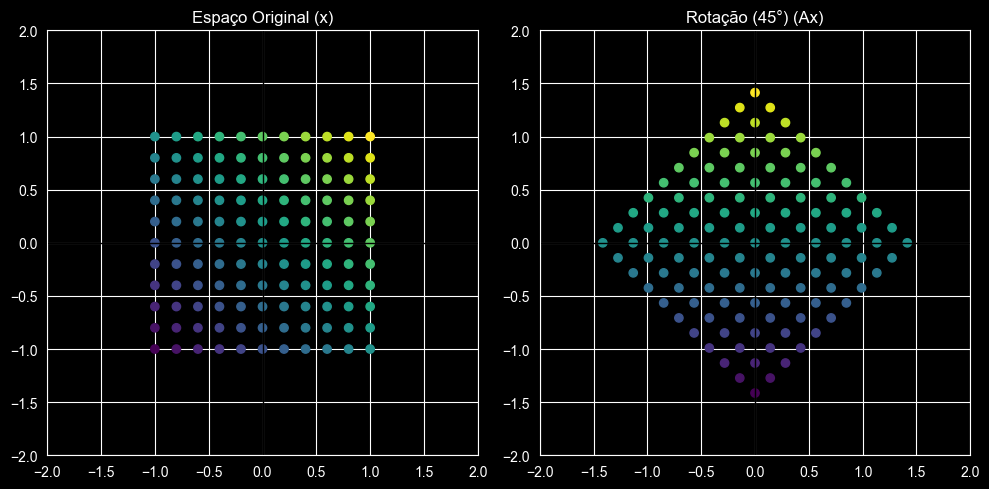

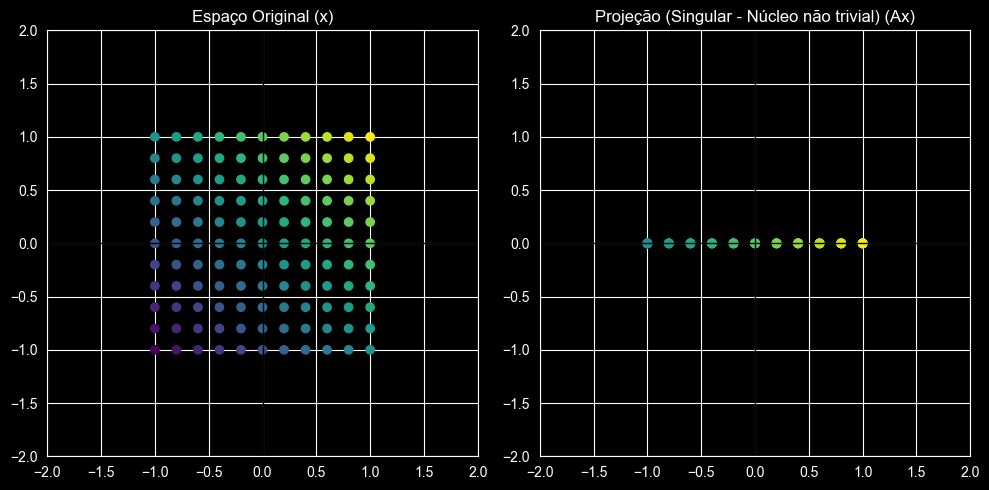

In [3]:
def plot_transformation(A, title="Transformação Linear"):
    # Criando uma grade de pontos
    x = np.linspace(-1, 1, 11)
    y = np.linspace(-1, 1, 11)
    xx, yy = np.meshgrid(x, y)
    
    # Vetores originais
    xy = np.vstack([xx.flatten(), yy.flatten()])
    
    # Aplicando a transformação
    xy_transformed = A @ xy
    
    # Plot
    plt.figure(figsize=(10, 5))
    
    # Espaço Original
    plt.subplot(1, 2, 1)
    plt.scatter(xy[0], xy[1], c=xy[0]+xy[1], cmap='viridis')
    plt.grid(True)
    plt.title("Espaço Original (x)")
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.xlim(-2, 2); plt.ylim(-2, 2)
    
    # Espaço Transformado
    plt.subplot(1, 2, 2)
    plt.scatter(xy_transformed[0], xy_transformed[1], c=xy[0]+xy[1], cmap='viridis')
    plt.grid(True)
    plt.title(f"{title} (Ax)")
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.xlim(-2, 2); plt.ylim(-2, 2)
    
    plt.tight_layout()
    plt.show()

# Testando com uma matriz de rotação de 45 graus
theta = np.radians(45)
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, -s], [s, c]])

plot_transformation(R, title="Rotação (45°)")

# Testando com uma matriz singular (projeção no eixo x)
P = np.array([[1, 0], [0, 0]])
plot_transformation(P, title="Projeção (Singular - Núcleo não trivial)")

---

## 8. Conclusão: A conexão com Ax=b

A interpretação funcional de $Ax=b$ nos dá ferramentas poderosas:

*   **Existência de solução:** $b$ está na imagem?
*   **Unicidade:** O núcleo é trivial? Se houver vetores no núcleo além do zero, podemos somar qualquer um deles a uma solução particular e obter outra solução válida ($A(x_p + x_h) = Ax_p + Ax_h = b + 0 = b$).
*   **Transformações Singulares:** Quando o posto é menor que $n$, a transformação "achata" o espaço (como vimos na Projeção), perdendo informação e tornando a matriz não invertível.

Essa visão une a álgebra abstrata à prática computacional, sendo a base para algoritmos de compressão, computação gráfica e aprendizado de máquina.
